### Reading the data and preprocessing it


In [1]:
#!pip install seaborn
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# At the beginning of your notebook or script, add these lines:
pd.options.mode.chained_assignment = None  # default='warn'
warnings.filterwarnings("ignore", category=UserWarning)
#We filter out files that only contain 9.5-10 seconds
def read_preprocessed_files(folder_path):
    file_paths = glob.glob(os.path.join(folder_path, '*.csv'))
    
    df_list = []
    for file_path in file_paths:
        df = pd.read_csv(file_path)
        df_list.append(df)
    
    return df_list
#results = read_preprocessed_files('/Users/ansh/Downloads/features_main')
results = read_preprocessed_files('Main_dataset_12k')
print(len(results))

for df in results:
    df['throughput'] = (df['sum_packet_length'] * 8 / 10e4)

# Display the first DataFrame in results as an example
print(results[0])
input_data=[]
for df in results:
    df_input = df
    
    bin_size = 2
    
    # Create bins
    df_input['bin'] = (df_input['time_bin'] // bin_size) * bin_size
    
    # Group by bin and calculate average throughput and other features
    df_result = df_input.groupby('bin').agg({
        'throughput': 'mean',
        'avg_bytes_in_flight': 'mean',
        'stddev_bytes_in_flight': 'mean',
        'avg_ack_rtt': 'mean',
        'stddev_ack_rtt': 'mean',
        'sum_packet_length': 'sum',
        'stddev_packet_length': 'mean',
        'avg_tcp_window_size': 'mean',
        'sum_retransmission': 'sum',
        'sum_duplicate_ack': 'sum'
    }).reset_index()
    
    # Rename columns
    df_result.columns = ['bin_start', 'avg_throughput', 'avg_bytes_in_flight', 'stddev_bytes_in_flight', 
                        'avg_ack_rtt', 'stddev_ack_rtt', 'sum_packet_length', 'stddev_packet_length', 
                        'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']
    
    # Add bin_end column
    df_result['bin_end'] = df_result['bin_start'] + bin_size
    
    # Reorder columns
    df_result = df_result[['bin_start', 'bin_end', 'avg_throughput', 'avg_bytes_in_flight', 'stddev_bytes_in_flight', 
                           'avg_ack_rtt', 'stddev_ack_rtt', 'sum_packet_length', 'stddev_packet_length', 
                           'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']]
    input_data.append(df_result)
# Print the result
print(input_data[1].columns)

11810
    time_bin  avg_bytes_in_flight  stddev_bytes_in_flight  avg_ack_rtt  \
0        0.0        103672.052632            97647.667833     0.007255   
1        1.0        485904.461538            76413.407706     0.044378   
2        2.0        524965.573770             2526.142196     0.128461   
3        3.0        545023.424460           144333.119015     0.105203   
4        4.0        394299.360000            83220.476622     0.072741   
..       ...                  ...                     ...          ...   
87      87.0         60086.697674             7154.738712     0.014848   
88      88.0         54621.470000            23355.432448     0.011581   
89      89.0         71542.800000            24216.162952     0.031179   
90      90.0         75333.263158            30686.970672     0.009393   
91      91.0         99054.000000            34371.907843     0.026987   

    stddev_ack_rtt  sum_packet_length  stddev_packet_length  \
0         0.004684             928049     

In [2]:
input_data_store = input_data

### Splitting data into the train and eval set ( train set will be randomly split while training NN and RF)| Done to avoid data leakage

In [3]:
input_data = input_data_store[:10000]
input_data_eval = input_data_store[10000:]

### Defining our NN 

In [7]:
### Defining our NN model

import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.tensorboard import SummaryWriter  # Add this import
import torch 
from torch import nn
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')
def evaluate_accuracy(model, X_test, y_test):
    model.eval()  # Set the model to evaluation mode
    with torch.no_grad():
        # Ensure X_test is a tensor and on the correct device
        X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
        y_test = torch.tensor(y_test, dtype=torch.long).to(device)
        
        # Get model outputs
        outputs = model(X_test)
        
        # Get predicted class (0 or 1)
        _, predicted = torch.max(outputs, 1)
        
        # Calculate the number of correct predictions
        correct = (predicted == y_test).sum().item()
        total = y_test.size(0)
        accuracy = 100 * correct / total
        print('y_test: ',y_test)
        print('predicted: ',predicted)
    return accuracy,predicted
def compute_confusion_matrix(model, X, y):
    model.eval()
    with torch.no_grad():
        X = torch.tensor(X, dtype=torch.float32).to(device)
        y = torch.tensor(y, dtype=torch.long).to(device)
        
        outputs = model(X)
        _, predicted = torch.max(outputs, 1)
        
        y_true = y.cpu().numpy()
        y_pred = predicted.cpu().numpy()
        
        print(f"Shape of y_true: {y_true.shape}")
        print(f"Shape of y_pred: {y_pred.shape}")
        print(f"Unique values in y_true: {np.unique(y_true)}")
        print(f"Unique values in y_pred: {np.unique(y_pred)}")
        
        cm = confusion_matrix(y_true, y_pred)
        return cm
def plot_confusion_matrix(cm):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix')
    plt.show()
def plot_pie_chart(y):
    # Count occurrences of each type
    unique, counts = np.unique(y, axis=0, return_counts=True)
    labels = [f'{tuple(label)}' for label in unique]
    total_count = sum(counts)
    for i in range(len(unique)):
        print('Labels: ',labels[i],'Availability: ',np.round(counts[i]/total_count,2))
    # Plotting the pie chart
    #plt.figure(figsize=(3, 3))
    #plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=140)
    #plt.title('Frequency Split of y Values')
    #plt.show()

def train_and_evaluate_model(X, y,tau=40, num_epochs=100, hidden_size=100, batch_size=64, learning_rate=0.001):
    def predict(output):
        softmax = nn.Softmax(dim=1)
        probabilities = softmax(output)
        binary_predictions = (probabilities > 0.5).float()
        return binary_predictions.numpy()
    #Standardizing the data ( truncating or padding to fit the input size)
    def standardize_df(df, target_len):
        if len(df) < target_len:
            padding = pd.DataFrame(0, index=range(target_len - len(df)), columns=df.columns)
            return pd.concat([df, padding], ignore_index=True)
        else:
            return df.iloc[:target_len]

    
    
    #filtered_combined = [df[df['bin_start'] <= tau] for df in X]
    max_len = max(len(df) for df in X)
    bin_size = 2
    x_standardized = [standardize_df(df, tau//bin_size) for df in X]
    def standardize_df_shape(df_list, target_rows):

        standardized_dfs = []
        for df in df_list:
            if df.shape[0] < target_rows:
                # Pad with zeros
                padding = pd.DataFrame(0, index=range(target_rows - df.shape[0]), columns=df.columns)
                standardized_df = pd.concat([df, padding], ignore_index=True)
            else:
                # Truncate
                standardized_df = df.iloc[:target_rows]
            standardized_dfs.append(standardized_df)
        return standardized_dfs
    def prepare_training_data(X, y):
   
    # Find the maximum number of rows in any DataFrame
        max_rows = max(df.shape[0] for df in X)
        
        # Standardize DataFrame shapes
        X_standardized = standardize_df_shape(X, max_rows)
        
        # Convert to numpy array
        X = np.array([df[['avg_throughput', 'avg_bytes_in_flight', 'stddev_bytes_in_flight',
                         'avg_ack_rtt', 'stddev_ack_rtt', 'sum_packet_length',
                         'stddev_packet_length', 'avg_tcp_window_size',
                         'sum_retransmission', 'sum_duplicate_ack']].values.flatten() for df in X_standardized])
        y = np.array(y)
        
        scaler = MinMaxScaler()
        X = scaler.fit_transform(X)
        
        
        
        return X, y
    # Add this before calling prepare_training_data
    
    X, y = prepare_training_data(X, y)


    print(f"Shape of X: {X.shape}")

    X_temp, X_eval, y_temp, y_eval = train_test_split(X, y, test_size=100, random_state=42)
    X_train, X_test, y_train, y_test = train_test_split(X_temp, y_temp, test_size=0.1, random_state=42)

    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    X_eval = torch.tensor(X_eval, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test = torch.tensor(y_test, dtype=torch.float32).to(device)
    y_eval = torch.tensor(y_eval, dtype=torch.float32).to(device)

    print(f"Shape of X_train: {X_train.shape}")
    print(f"Shape of y_train: {y_train.shape}")

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    class NeuralNetwork(nn.Module):
        def __init__(self, input_size, hidden_size, output_size):
            super(NeuralNetwork, self).__init__()
            self.layer1 = nn.Linear(input_size, hidden_size)
            self.layer2 = nn.Linear(hidden_size, hidden_size)
            self.layer3 = nn.Linear(hidden_size, 2)  # Changed to 2 for binary classification
            self.elu = nn.ELU()
            self.sigmoid = nn.Sigmoid()

        def forward(self, x):
            x = x.reshape(x.size(0), -1)
            x = self.elu(self.layer1(x))
            x = self.elu(self.layer2(x))
            x = self.layer3(x)  # Output logits for binary classification
            return x

    n_samples, n_features = X_train.shape
    input_size =  n_features
    output_size = 1

    model = NeuralNetwork(input_size, hidden_size, output_size).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    writer = SummaryWriter()

    loss_values = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        loss_values.append(avg_loss)

        writer.add_scalar('Loss/train', avg_loss, epoch)

        '''if epoch % 10 == 0:
            train_accuracy = evaluate_accuracy(model, X_train, y_train)
            test_accuracy = evaluate_accuracy(model, X_test, y_test)
            writer.add_scalar('Accuracy/train', train_accuracy, epoch)
            writer.add_scalar('Accuracy/test', test_accuracy, epoch)'''

    test_accuracy,predicted_test = evaluate_accuracy(model, X_test, y_test)
    eval_accuracy,predicted_eval = evaluate_accuracy(model, X_eval, y_eval)

    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Evaluation Set Accuracy: {eval_accuracy:.2f}%")

    writer.add_scalar('Accuracy/final_test', test_accuracy, 0)
    writer.add_scalar('Accuracy/final_eval', eval_accuracy, 0)

    try:
        test_cm = compute_confusion_matrix(model, X_test, y_test)
        print("Confusion Matrix for Test Set:")
        print(test_cm)
        print(f"True Negatives: {test_cm[0][0]}")
        print(f"False Positives: {test_cm[0][1]}")
        print(f"False Negatives: {test_cm[1][0]}")
        print(f"True Positives: {test_cm[1][1]}")
        plot_confusion_matrix(test_cm)
    except Exception as e:
        print(f"Error computing confusion matrix: {str(e)}")
        print("Skipping confusion matrix plot.")

#    plot_pie_chart(y)
    writer.close()

    return model, test_accuracy, eval_accuracy,X_train.cpu().numpy(),y_train.cpu().numpy(),X_test.cpu().numpy(),y_test.cpu().numpy(),predicted_test,predicted_eval


Using device: mps


In [5]:
x_combined = []
y_combined = []
within_5_percent = []
more_than_10_percent = []
tau = 20
#Function to check if the average of tau second window is within some threshold deviation of the total average 
def within_deviation(df,tau,threshold):#threshold -> deviation
    index_label = df[df['bin_start'] >= tau].index[0]
    avg_within_tau = np.mean(df['avg_throughput'].iloc[:index_label])
    overall_avg = np.mean(df['avg_throughput'])
    if abs((overall_avg-avg_within_tau)/overall_avg) <= threshold/100:
        return True
    return False

def scale_features(df):
        scaler = MinMaxScaler()
        feature_columns = ['avg_throughput', 'avg_bytes_in_flight', 'stddev_bytes_in_flight',
                       'avg_ack_rtt', 'stddev_ack_rtt', 'sum_packet_length',
                       'stddev_packet_length', 'avg_tcp_window_size',
                       'sum_retransmission', 'sum_duplicate_ack']
    
        # Ensure no NaN values before scaling
        
        df[feature_columns] = df[feature_columns].fillna(0)
    
        df[feature_columns] = scaler.fit_transform(df[feature_columns])
        return df

for df in input_data[:]:
    if within_deviation(df, tau, 20):
        within_5_percent.append((df, 1))
    elif not within_deviation(df, tau, 25):
        more_than_10_percent.append((df, 0))

for i in within_5_percent:
    x_combined.append(i[0][[ 'avg_throughput', 'avg_bytes_in_flight', 
                             'stddev_bytes_in_flight', 'avg_ack_rtt', 'stddev_ack_rtt',
                             'sum_packet_length', 'stddev_packet_length', 
                             'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']])
    y_combined.append(i[1])
for i in more_than_10_percent:
    x_combined.append(i[0][['avg_throughput', 'avg_bytes_in_flight', 
                             'stddev_bytes_in_flight', 'avg_ack_rtt', 'stddev_ack_rtt',
                             'sum_packet_length', 'stddev_packet_length', 
                             'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']])
    y_combined.append(i[1])

# Scale Features
x_combined_scaled = [scale_features(df) for df in x_combined]
print(len(within_5_percent))
print(len(more_than_10_percent))

5629
3705


Shape of X: (9334, 580)
Shape of X_train: torch.Size([8310, 580])
Shape of y_train: torch.Size([8310])
y_test:  tensor([1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
        1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
        1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1,
        1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
        0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
        1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
        0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1,
        0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
        

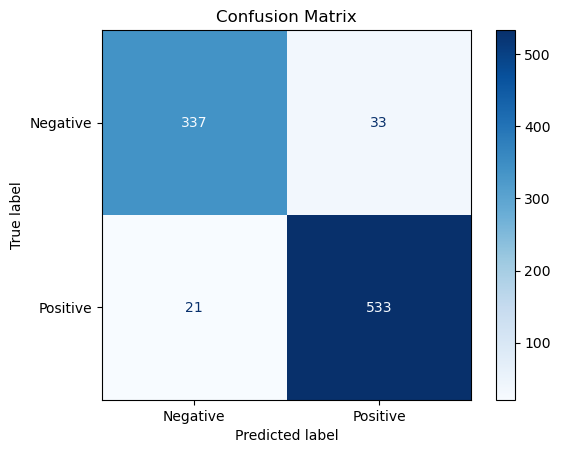

In [8]:
model_nn, test_acc, eval_acc, X_train,y_train,X_test,y_test,predicted_test,predicted_eval = train_and_evaluate_model(x_combined, y_combined,tau=tau, hidden_size=250)


In [7]:
X_train

array([[0.5335648 , 0.        , 0.06436583, ..., 0.        , 0.        ,
        0.        ],
       [0.33185914, 0.        , 1.        , ..., 0.        , 0.        ,
        0.        ],
       [0.13399854, 0.12454547, 0.31080264, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.13324043, 0.0599951 , 0.1152732 , ..., 1.        , 0.2601705 ,
        0.2601705 ],
       [0.09509697, 0.4967659 , 0.7620915 , ..., 0.        , 0.        ,
        0.        ],
       [0.06099157, 0.01601334, 0.03351988, ..., 0.6540587 , 0.1977887 ,
        0.1977887 ]], dtype=float32)

In [8]:
x_combined_alt = []
y_combined_alt = []
within_5_percent_alt = []
more_than_10_percent_alt = []
#Function to check if the average of tau second window is within some threshold deviation of the total average 
def within_deviation(df,tau,threshold):#threshold -> deviation
    index_label = df[df['bin_start'] >= tau].index[0]
    avg_within_tau = np.mean(df['avg_throughput'].iloc[:index_label])
    overall_avg = np.mean(df['avg_throughput'])
    if abs((overall_avg-avg_within_tau)/overall_avg) <= threshold/100:
        return True
    return False

def scale_features(df):
        scaler = MinMaxScaler()
        feature_columns = df.columns
    
        # Ensure no NaN values before scaling
        
        df[feature_columns] = df[feature_columns].fillna(0)
    
        df[feature_columns] = scaler.fit_transform(df[feature_columns])
        return df

for df in input_data_eval:
    if within_deviation(df, tau, 20):
        within_5_percent_alt.append((df, 1))
    elif not within_deviation(df, tau, 25):
        more_than_10_percent_alt.append((df, 0))

for i in within_5_percent_alt:
    x_combined_alt.append(i[0][[ 'avg_throughput','avg_bytes_in_flight', 
                             'stddev_bytes_in_flight', 'avg_ack_rtt', 'stddev_ack_rtt',
                             'sum_packet_length', 'stddev_packet_length', 
                             'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']])
    y_combined_alt.append(i[0])


# Scale Features
x_combined_scaled_alt = [scale_features(df) for df in x_combined_alt]

print(len(within_5_percent_alt))
print(len(more_than_10_percent_alt))

992
682


In [9]:
x_combined_rf = []
y_combined_rf = []
for i in within_5_percent:
    x_combined_rf.append(i[0][['avg_bytes_in_flight', 'stddev_bytes_in_flight', 'avg_ack_rtt', 'stddev_ack_rtt',
                             'sum_packet_length', 'stddev_packet_length', 
                             'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']])
    y_combined_rf.append(i[0]['avg_throughput'])

In [10]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

def train_and_evaluate_rf_modified(X_list, y_list, tau=20, test_size=0.2, test_margin=0.1):
    """
    Train RF model using only first tau rows of each DataFrame
    """
    # First, convert list of dataframes to a single matrix
    X_truncated = []
    y_truncated = []
    
    for df, y_series in zip(X_list, y_list):
        # Take only first tau rows
        df_truncated = df.iloc[:tau]
        
        # Skip if DataFrame has fewer than tau rows
        if len(df_truncated) < tau:
            continue
            
        # Convert DataFrame to numpy array
        features = df_truncated.values
        
        # Get the mean value for y if it's a series/dataframe
        if isinstance(y_series, (pd.Series, pd.DataFrame)):
            y_val = y_series.mean()
        else:
            y_val = y_series
            
        X_truncated.append(features)
        y_truncated.append(y_val)
    
    # Convert to numpy arrays
    X = np.array([x.flatten() for x in X_truncated])  # Flatten each matrix
    y = np.array(y_truncated, dtype=np.float32)  # Ensure y is a simple float array
    
    print(f"Input shape after truncation: X={X.shape}, y={y.shape}")
    print(f"Number of features per time step: {X.shape[1]//tau}")
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    
    # Scale the features
    scaler_X = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Scale the target variable
    scaler_y = MinMaxScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))

    # Train Random Forest model
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_scaled, y_train_scaled.ravel())

    # Make predictions
    y_pred_normalized = rf.predict(X_test_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_normalized.reshape(-1, 1))

    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Calculate accuracy within margin
    correct = sum(1 for i in range(len(y_pred)) 
                 if (1-test_margin)*y_test[i] <= y_pred[i][0] <= (1+test_margin)*y_test[i])
    accuracy = 100 * correct / len(y_pred)

    # Print results
    print('\nModel Performance Metrics:')
    print(f'Mean Squared Error: {mse:.4f}')
    print(f'R2 Score: {r2:.4f}')
    print(f'Mean Absolute Error: {mae:.4f}')
    print(f'Test accuracy (within {test_margin*100}% deviation): {accuracy:.2f}%')

    # Save model and scalers
    os.makedirs('models', exist_ok=True)
    joblib.dump(rf, 'models/random_forest_model.joblib')
    joblib.dump(scaler_X, 'models/scaler_X.joblib')
    joblib.dump(scaler_y, 'models/scaler_y.joblib')
    
    return rf, scaler_X, scaler_y

# Usage
model_rf, scaler_X, scaler_y = train_and_evaluate_rf_modified(x_combined_rf, y_combined_rf, tau=20)


Input shape after truncation: X=(5596, 180), y=(5596,)
Number of features per time step: 9

Model Performance Metrics:
Mean Squared Error: 4971.6769
R2 Score: 0.8677
Mean Absolute Error: 8.8222
Test accuracy (within 10.0% deviation): 78.21%


### Labelling the data for evaluation (Composite Model)

In [11]:
input_data_eval_final=[]
temp_alt2=[]
for i in input_data_eval:
    if within_deviation(i, tau, 30):
        input_data_eval_final.append(i)
    else:
        temp_alt2.append(i)
input_data_eval_final.extend(temp_alt2[:200])


In [12]:
len(input_data_eval_final),len(input_data_eval),len(temp_alt2)

(1414, 1810, 596)

### Composite Model


Random Forest Model Statistics:
Mean deviation: 24.52%
Median deviation: 5.36%
Std deviation: 145.14%

Positive Composite Model Statistics:
Number of samples used: 823
Mean deviation: 8.13%
Median deviation: 4.05%
Std deviation: 14.01%

Negative Composite Model Statistics:
Number of samples used: 586
Mean deviation: 45.35%
Median deviation: 8.64%
Std deviation: 217.17%

Data Savings Statistics:
Mean saving: 47.60%
Median saving: 79.65%
Std saving: 40.43%


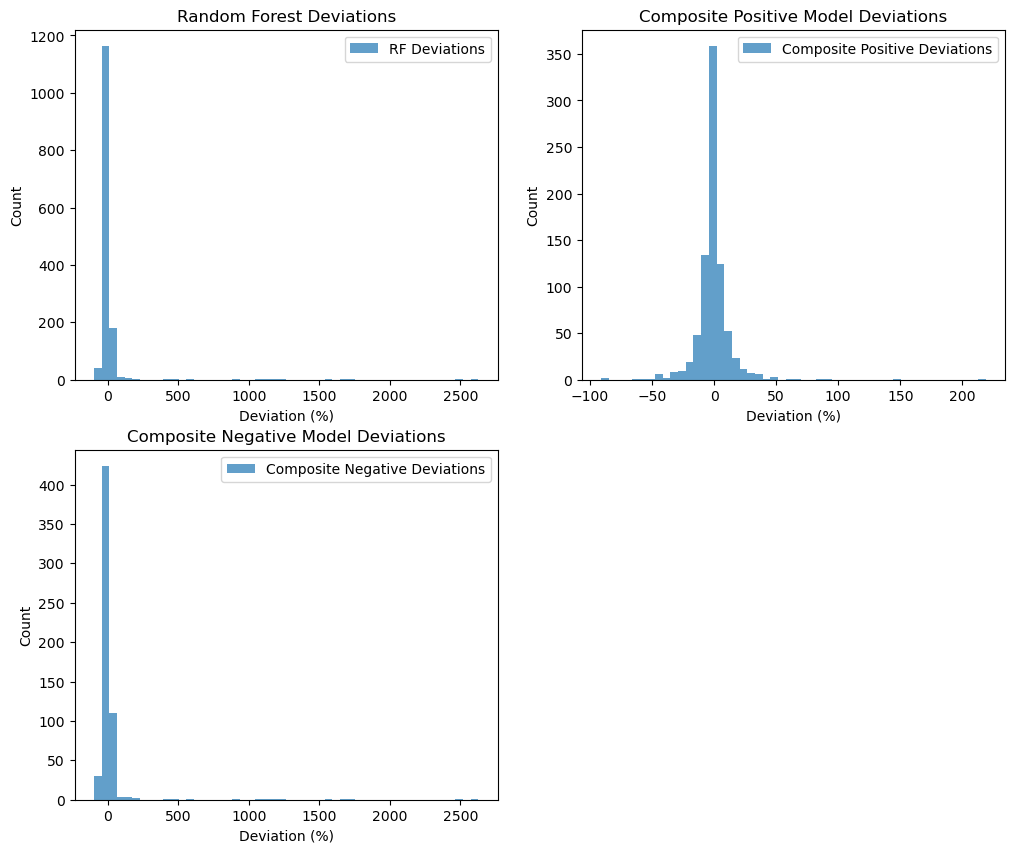

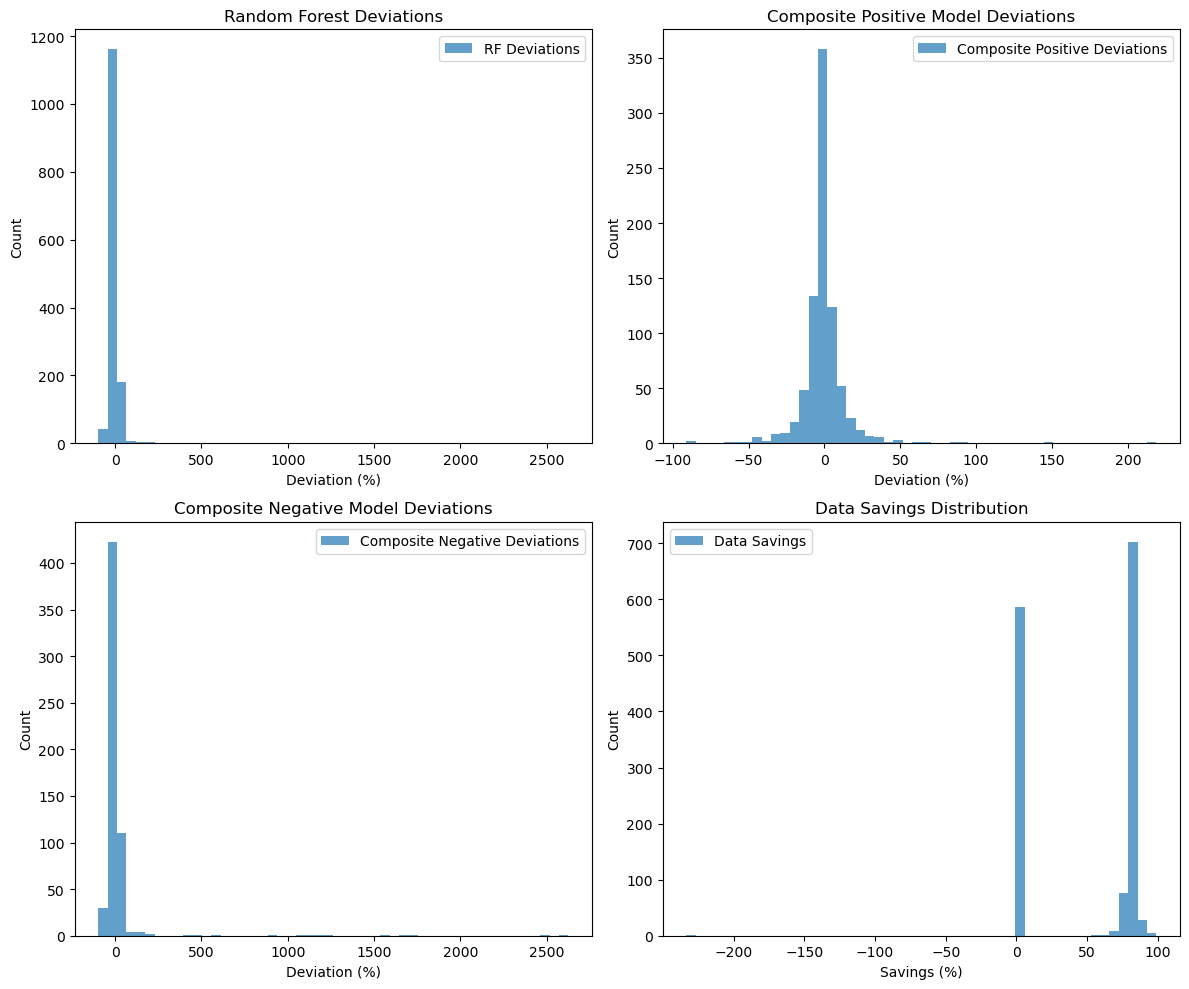

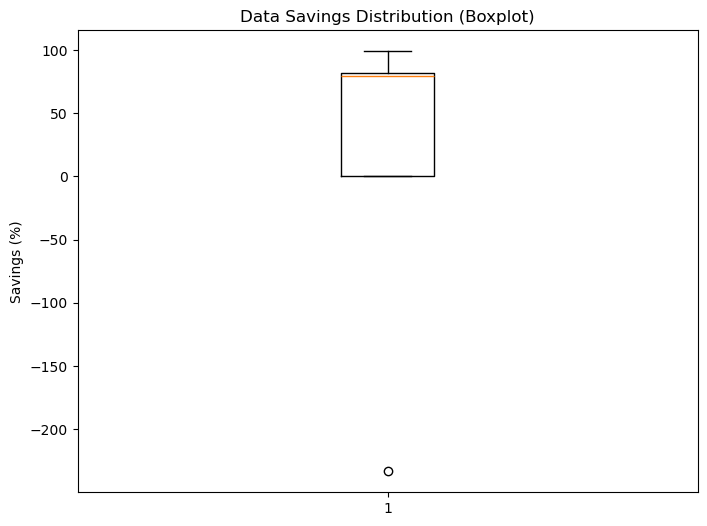

In [13]:
# Lists to store deviations
rf_deviations = []
composite_positive_deviations = []
composite_negative_deviations = []
data_savings = []
stable_throughput_deviations = []
stable_data_savings = []
# Get the expected input size for the neural network
input_size = model_nn.layer1.weight.shape[1]  # Get the expected input size from the model

# Process each DataFrame
for df in input_data_eval_final:
    # Get actual average throughput
    actual_throughput = df['avg_throughput'].mean()
    
    try:
        # Prepare data for NN classification
        df_features = df[['avg_throughput', 'avg_bytes_in_flight', 'stddev_bytes_in_flight',
                        'avg_ack_rtt', 'stddev_ack_rtt', 'sum_packet_length',
                        'stddev_packet_length', 'avg_tcp_window_size',
                        'sum_retransmission', 'sum_duplicate_ack']][:tau]
        
        # Ensure df has correct length
        if len(df_features) < tau:
            # Pad with zeros if necessary
            padding = pd.DataFrame(0, index=range(tau - len(df_features)), columns=df_features.columns)
            df_features = pd.concat([df_features, padding], ignore_index=True)
        
        # Flatten and ensure correct input size
        X_nn = df_features.values.flatten()
        if len(X_nn) != input_size:
            # Pad or truncate to match expected input size
            if len(X_nn) < input_size:
                X_nn = np.pad(X_nn, (0, input_size - len(X_nn)))
            else:
                X_nn = X_nn[:input_size]
        
        X_nn = torch.tensor(X_nn, dtype=torch.float32).unsqueeze(0).to(device)
        
        # Get NN prediction
        model_nn.eval()
        with torch.no_grad():
            outputs = model_nn(X_nn)
            _, predicted = torch.max(outputs, 1)
            #print(predicted)
            is_stable = predicted.item() == 0
            is_unstable = predicted.item() == -1
            
        # Prepare data for RF
        df_rf = df[['avg_bytes_in_flight', 'stddev_bytes_in_flight', 'avg_ack_rtt', 
                    'stddev_ack_rtt', 'sum_packet_length', 'stddev_packet_length',
                    'avg_tcp_window_size', 'sum_retransmission', 'sum_duplicate_ack']][:tau]
        
        # Ensure RF input has correct shape
        if len(df_rf) < tau:
            padding = pd.DataFrame(0, index=range(tau - len(df_rf)), columns=df_rf.columns)
            df_rf = pd.concat([df_rf, padding], ignore_index=True)
        
        X_rf = df_rf.values.flatten().reshape(1, -1)
        X_rf_scaled = scaler_X.transform(X_rf)
        
        # Get RF prediction
        rf_pred_scaled = model_rf.predict(X_rf_scaled)
        rf_pred = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1))[0][0]
        
        # Calculate RF deviation
        rf_deviation = ((rf_pred - actual_throughput) / actual_throughput) * 100
        rf_deviations.append(rf_deviation)
        
        # For composite model: use RF prediction only if NN predicts stable (1)
        if is_stable:
            composite_positive_deviation = ((rf_pred - actual_throughput) / actual_throughput) * 100
            composite_positive_deviations.append(composite_positive_deviation)
            overall_avg = df['avg_throughput'].mean()*len(df)*2
            tau_avg = df['avg_throughput'][:tau].mean()*tau
            saving = ((overall_avg - tau_avg) / overall_avg) * 100
            data_savings.append(saving)
            abs_deviation = abs((rf_pred - actual_throughput) / actual_throughput) * 100
            stable_throughput_deviations.append(abs_deviation)
            stable_data_savings.append(saving)
            '''stable_throughput_threshold = np.percentile(stable_throughput_deviations, 95)
            
            # Filter out outliers
            for dev , saving in zip(stable_throughput_deviations,stable_data_savings):
                if dev <= stable_throughput_threshold:
                    stable_throughput_deviations.append(dev)
                    stable_data_savings.append(saving)'''
        if is_unstable:

            composite_negative_deviation = ((rf_pred - actual_throughput) / actual_throughput) * 100
            composite_negative_deviations.append(composite_negative_deviation)
            data_savings.append(0)
    except Exception as e:
        print(f"Error processing DataFrame: {str(e)}")
        continue

# Print statistics
if rf_deviations and composite_positive_deviations and composite_negative_deviations:  # Check if lists are not empty
    print("\nRandom Forest Model Statistics:")
    print(f"Mean deviation: {np.mean(np.abs(rf_deviations)):.2f}%")
    print(f"Median deviation: {np.median(np.abs(rf_deviations)):.2f}%")
    print(f"Std deviation: {np.std(np.abs(rf_deviations)):.2f}%")

    print("\nPositive Composite Model Statistics:")
    print(f"Number of samples used: {len(composite_positive_deviations)}")
    print(f"Mean deviation: {np.mean(np.abs(composite_positive_deviations)):.2f}%")
    print(f"Median deviation: {np.median(np.abs(composite_positive_deviations)):.2f}%")
    print(f"Std deviation: {np.std(np.abs(composite_positive_deviations)):.2f}%")

    print("\nNegative Composite Model Statistics:")
    print(f"Number of samples used: {len(composite_negative_deviations)}")
    print(f"Mean deviation: {np.mean(np.abs(composite_negative_deviations)):.2f}%")
    print(f"Median deviation: {np.median(np.abs(composite_negative_deviations)):.2f}%")
    print(f"Std deviation: {np.std(np.abs(composite_negative_deviations)):.2f}%")
    # Plot distributions
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.hist(rf_deviations, bins=50, alpha=0.7, label='RF Deviations')
    plt.title('Random Forest Deviations')
    plt.xlabel('Deviation (%)')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.hist(composite_positive_deviations, bins=50, alpha=0.7, label='Composite Positive Deviations')
    plt.title('Composite Positive Model Deviations')
    plt.xlabel('Deviation (%)')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.hist(composite_negative_deviations, bins=50, alpha=0.7, label='Composite Negative Deviations')
    plt.title('Composite Negative Model Deviations')
    plt.xlabel('Deviation (%)')
    plt.ylabel('Count')
    plt.legend()

    
else:
    print("No valid predictions were generated.")

if data_savings:  # Check if list is not empty
    print("\nData Savings Statistics:")
    print(f"Mean saving: {np.mean(np.abs(data_savings)):.2f}%")
    print(f"Median saving: {np.median(np.abs(data_savings)):.2f}%")
    print(f"Std saving: {np.std(np.abs(data_savings)):.2f}%")

    # Update plot to include data savings
    plt.figure(figsize=(12, 10))

    plt.subplot(2, 2, 1)
    plt.hist(rf_deviations, bins=50, alpha=0.7, label='RF Deviations')
    plt.title('Random Forest Deviations')
    plt.xlabel('Deviation (%)')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(2, 2, 2)
    plt.hist(composite_positive_deviations, bins=50, alpha=0.7, label='Composite Positive Deviations')
    plt.title('Composite Positive Model Deviations')
    plt.xlabel('Deviation (%)')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(2, 2, 3)
    plt.hist(composite_negative_deviations, bins=50, alpha=0.7, label='Composite Negative Deviations')
    plt.title('Composite Negative Model Deviations')
    plt.xlabel('Deviation (%)')
    plt.ylabel('Count')
    plt.legend()

    plt.subplot(2, 2, 4)  # New subplot for data savings
    plt.hist(data_savings, bins=50, alpha=0.7, label='Data Savings')
    plt.title('Data Savings Distribution')
    plt.xlabel('Savings (%)')
    plt.ylabel('Count')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Additional plot for data savings boxplot
    plt.figure(figsize=(8, 6))
    plt.boxplot(data_savings)
    plt.title('Data Savings Distribution (Boxplot)')
    plt.ylabel('Savings (%)')
    plt.show()
else:
    print("No valid predictions or savings were generated.")

<Figure size 640x480 with 0 Axes>


Summary Statistics for Stable Cases:
Number of stable cases: 818
Average throughput deviation: 7.40%
Average data savings: 81.35%


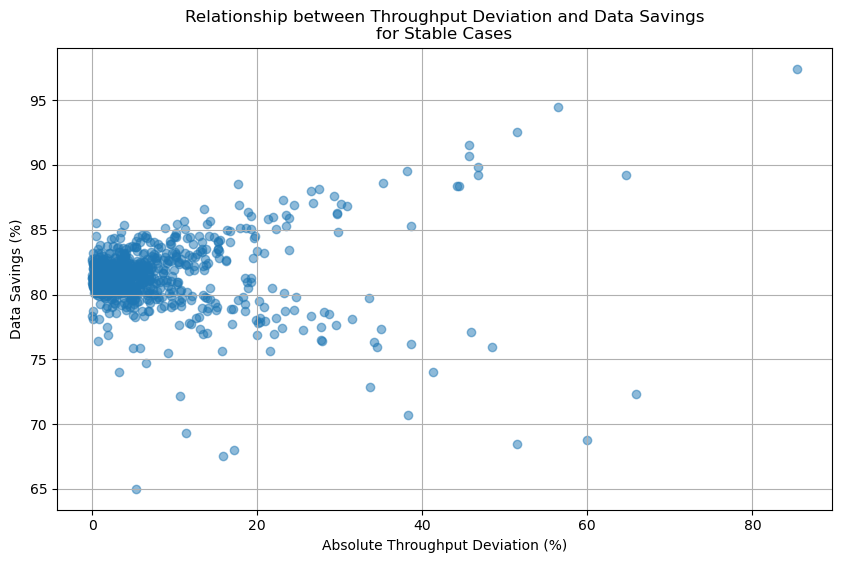

In [17]:
plt.tight_layout()
plt.show()

# Zip the lists and sort based on throughput deviations
zipped_data = list(zip(stable_throughput_deviations, stable_data_savings))
sorted_zipped_data = sorted(zipped_data, key=lambda x: x[0])

# Remove the last 5 points
sorted_zipped_data = sorted_zipped_data[:-5]

# Unzip the sorted and trimmed data
sorted_throughput_deviations, sorted_data_savings = zip(*sorted_zipped_data)

plt.figure(figsize=(10, 6))
plt.scatter(sorted_throughput_deviations, sorted_data_savings, alpha=0.5)
plt.xlabel('Absolute Throughput Deviation (%)')
plt.ylabel('Data Savings (%)')
plt.title('Relationship between Throughput Deviation and Data Savings\nfor Stable Cases')
plt.grid(True)

# Print summary statistics
print("\nSummary Statistics for Stable Cases:")
print(f"Number of stable cases: {len(sorted_throughput_deviations)}")
print(f"Average throughput deviation: {np.mean(sorted_throughput_deviations):.2f}%")
print(f"Average data savings: {np.mean(sorted_data_savings):.2f}%")
#print(f"Correlation coefficient: {correlation:.2f}")

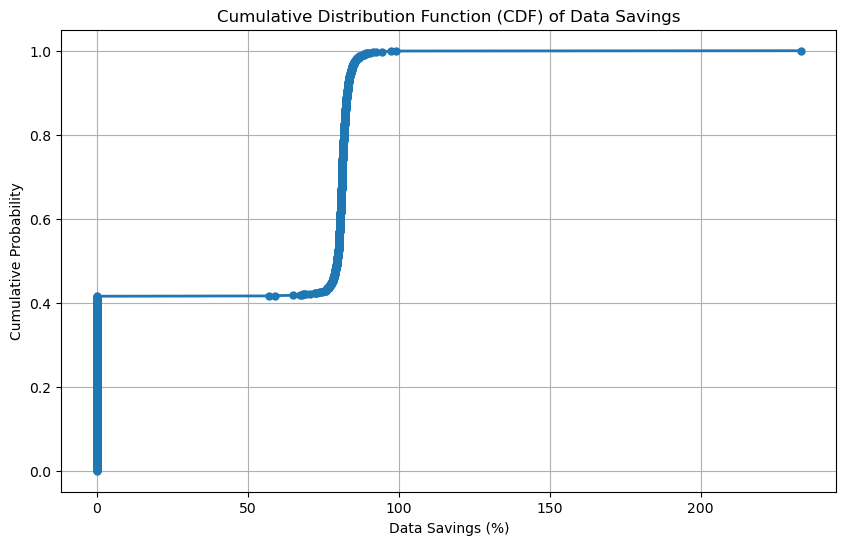

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the Cumulative Distribution Function (CDF) of data savings
sorted_data_savings = np.sort(np.abs(data_savings))
cdf = np.arange(1, len(sorted_data_savings) + 1) / len(sorted_data_savings)

# Plot the CDF
plt.figure(figsize=(10, 6))
plt.plot(sorted_data_savings, cdf, marker='.', linestyle='-', linewidth=2, markersize=10)
plt.title('Cumulative Distribution Function (CDF) of Data Savings')
plt.xlabel('Data Savings (%)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.show()

In [16]:
X_train.cpu().numpy()

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [18]:
# Save the models
import torch
import os
import joblib

# Create a directory to store the models if it doesn't exist
model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

# Save the neural network model
model_path = os.path.join(model_dir, 'neural_network_model.pth')
torch.save(model_nn, model_path)

# Save the neural network model state dictionary
state_dict_path = os.path.join(model_dir, 'model_state_dict.pth')
torch.save(model_nn.state_dict(), state_dict_path)

# Save the random forest model
rf_model_path = os.path.join(model_dir, 'random_forest_model.joblib')
joblib.dump(model_rf, rf_model_path)

print(f"Neural Network Model saved to {model_path}")
print(f"Neural Network Model state dictionary saved to {state_dict_path}")
print(f"Random Forest Model saved to {rf_model_path}")

# To load the models later, you can use:
"""
# Load complete neural network model
loaded_nn_model = torch.load(model_path)
loaded_nn_model.eval()  # Set to evaluation mode

# OR, if you want to load just the state dict into a new model instance:
new_model = NeuralNetwork(input_size, hidden_size, output_size)
new_model.load_state_dict(torch.load(state_dict_path))
new_model.eval()

# Load random forest model
loaded_rf_model = joblib.load(rf_model_path)
"""

AttributeError: Can't pickle local object 'train_and_evaluate_model.<locals>.NeuralNetwork'

In [1]:
print('Solution count 6: 140 150 160 ... 340')

Solution count 6: 140 150 160 ... 340
